In [21]:
import sys
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [23]:
df=pd.read_csv(r"C:\Users\eshan\Downloads\archive (3)\StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
x=df.drop("math score",axis=1)

In [25]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [26]:
y=df["math score"]  
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [27]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_features = x.select_dtypes(exclude="object").columns
cat_features = x.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", oh_transformer, cat_features)
    ]
)

In [ ]:
x = preprocessor.fit_transform(x)


In [29]:
x.shape

(1000, 19)

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape,

((800, 19), (200, 19))

In [32]:
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2_square=r2_score(true,predicted)
    return mae, rmse, r2_square


In [34]:
models={
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
    "k-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(verbose=False),
    "AdaBoostRegressor": AdaBoostRegressor()}
model_list=[]
r2_list=[]
for i in range(len(models)):
    model=list(models.values())[i]
    model.fit(x_train,y_train)
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)
    model_train_mae, model_train_rmse, model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2=evaluate_model(y_test,y_test_pred)
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    print("Model performance on training set")
    print("-root mean_absolute_error: {:.4f}".format(model_train_rmse)),
    print("-mean absolute_error: {:.4f}".format(model_train_mae)),
    print("-r2_score: {:.4f}".format(model_train_r2))
    print("----------------------------------")
    print("Model performance on test set")
    print("-root mean_squared_error: {:.4f}".format(model_test_rmse)),
    print("-mean absolute_error: {:.4f}".format(model_test_mae)),
    print("-r2_score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print('=' * 35)
    print("\n")



Linear Regression
Model performance on training set
-root mean_absolute_error: 5.3231
-mean absolute_error: 4.2667
-r2_score: 0.8743
----------------------------------
Model performance on test set
-root mean_squared_error: 5.3940
-mean absolute_error: 4.2148
-r2_score: 0.8804


Lasso Regression
Model performance on training set
-root mean_absolute_error: 6.5938
-mean absolute_error: 5.2063
-r2_score: 0.8071
----------------------------------
Model performance on test set
-root mean_squared_error: 6.5197
-mean absolute_error: 5.1579
-r2_score: 0.8253


Ridge Regression
Model performance on training set
-root mean_absolute_error: 5.3233
-mean absolute_error: 4.2650
-r2_score: 0.8743
----------------------------------
Model performance on test set
-root mean_squared_error: 5.3904
-mean absolute_error: 4.2111
-r2_score: 0.8806


k-Nearest Neighbors
Model performance on training set
-root mean_absolute_error: 5.7128
-mean absolute_error: 4.5168
-r2_score: 0.8552
---------------------------

In [35]:
pd.DataFrame({"Model":model_list, "R2_Score":r2_list}).sort_values(by="R2_Score", ascending=False)

,Model,R2_Score
2,Ridge Regression,0.880593
0,Linear Regression,0.880433
8,AdaBoostRegressor,0.852136
5,Random Forest,0.851686
7,CatBoostRegressor,0.851632
1,Lasso Regression,0.825320
6,XGBRegressor,0.821221
3,k-Nearest Neighbors,0.783770
4,Decision Tree,0.758895


In [36]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test,y_pred)*100
print("accuracy of the model: {:.2f}%".format(score))

accuracy of the model: 88.04%


Text(0.5, 1.0, 'Actual vs Predicted Values')

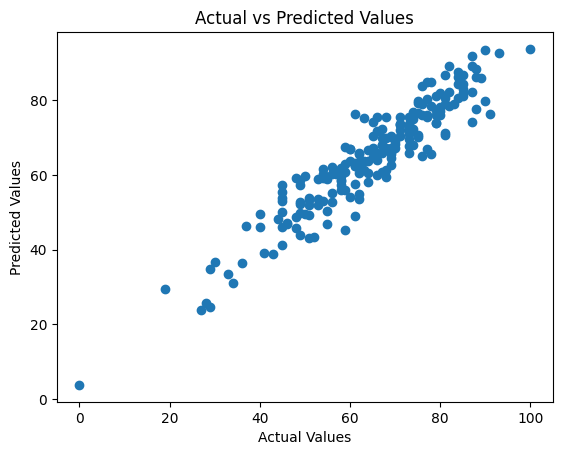

In [37]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

<Axes: xlabel='math score'>

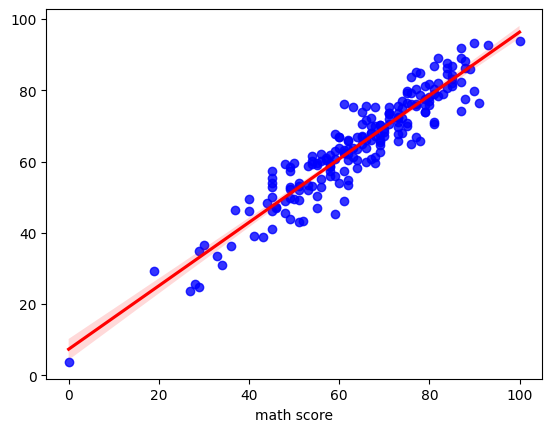

In [38]:
sns.regplot(x=y_test, y=y_pred, scatter_kws={"color": "blue"}, line_kws={"color": "red"})

In [39]:
pred_df=pd.DataFrame({"Actual":y_test, "Predicted":y_pred,"Difference": y_test-y_pred})
pred_df

,Actual,Predicted,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
